In [242]:
import pandas as pd

# load dataset
df = pd.read_csv("combined_with_distances.csv")

# preview
#print(df.head())

# check missing values
print(df.isnull().sum())

Place_ID           0
Place_Name         0
City               6
Province           0
Category           0
Latitude           0
Longitude          0
Terrain_Type       0
Time_Needed (H)    0
Rating             0
real_distance      9
dtype: int64


In [243]:
# remove duplicates
df = df.drop_duplicates()

# handle missing values (simple approach)
df = df.dropna()

# reset index
df = df.reset_index(drop=True)

print("Cleaned data shape:", df.shape)
print(df.isnull().sum())

Cleaned data shape: (727, 11)
Place_ID           0
Place_Name         0
City               0
Province           0
Category           0
Latitude           0
Longitude          0
Terrain_Type       0
Time_Needed (H)    0
Rating             0
real_distance      0
dtype: int64


In [244]:
features = df[['Latitude', 'Longitude']]


In [245]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [246]:
scaled_features

array([[-0.13230927,  0.09940346],
       [-0.15415092,  0.01536849],
       [-0.13538696,  0.09865147],
       ...,
       [-0.71667271, -0.12863775],
       [-0.8010609 , -0.09103821],
       [-0.7990753 , -0.09479816]], shape=(727, 2))

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

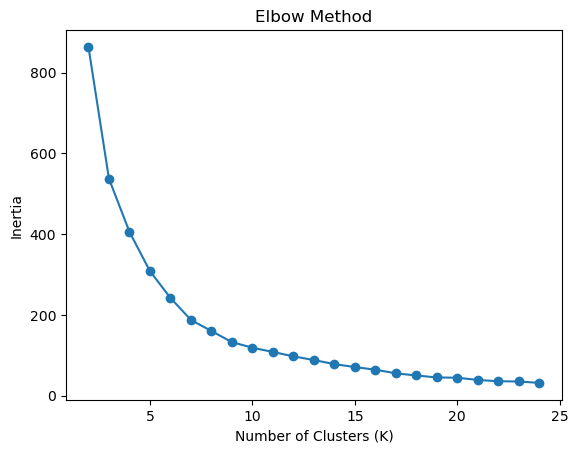

In [247]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 25)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# plot
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [248]:
kmeans = KMeans(n_clusters=18, random_state=42, n_init=10)

df['Cluster_ID'] = kmeans.fit_predict(scaled_features)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [249]:
print(df[['Place_Name', 'City', 'Cluster_ID']])

                                    Place_Name        City  Cluster_ID
0    Sri Dalada Maligawa (Temple of the Tooth)       Kandy          14
1           Royal Botanical Gardens Peradeniya  Peradeniya          14
2                         Kandy Lake Promenade       Kandy          14
3                  Bahirawakanda Buddha Statue       Kandy          14
4                  Udawattakele Forest Reserve       Kandy          14
..                                         ...         ...         ...
722           Godakawela Town & River Crossing  Godakawela          15
723             Godakawela Hot Springs (local)  Godakawela          15
724                       Opanayake Tea Trails   Opanayake           3
725                     Pelmadulla Town Market  Pelmadulla           3
726               Pelmadulla Scenic River Bend  Pelmadulla           3

[727 rows x 3 columns]


In [250]:
df["Cluster_ID"].value_counts()

Cluster_ID
4     64
6     54
9     54
3     54
0     51
2     46
7     43
8     43
15    43
14    41
16    41
13    39
1     37
10    34
5     27
11    21
12    19
17    16
Name: count, dtype: int64

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


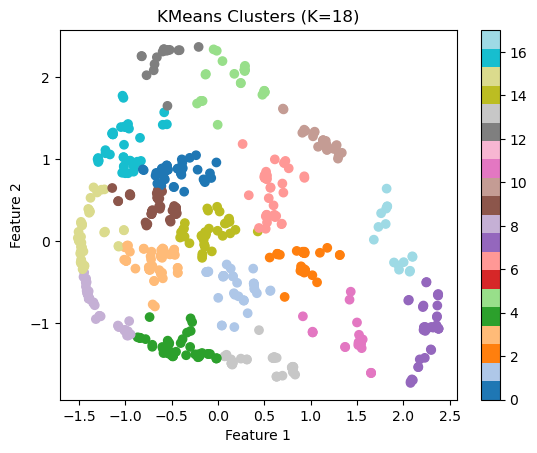

In [251]:
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=18, random_state=42)
labels = kmeans.fit_predict(scaled_features)

plt.scatter(scaled_features[:, 0], scaled_features[:, 1],
            c=labels, cmap='tab20')


plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KMeans Clusters (K=18)")
plt.colorbar()
plt.show()

In [252]:
for cluster_id in sorted(df['Cluster_ID'].unique()):
    print("\n=== Cluster", cluster_id, "===")
    print(df[df['Cluster_ID'] == cluster_id][['Place_Name', 'City']].head(10))


=== Cluster 0 ===
                          Place_Name                  City
255               Nine Arches Bridge                  Ella
256                        Ella Rock                  Ella
257               Little Adam's Peak                  Ella
258                     Ravana Falls                  Ella
259                      Ravana Cave                  Ella
260  Demodara Railway Loop & Station              Demodara
261                Kithal Ella Falls           Kithal Ella
262           Dowa Rajamaha Viharaya           Bandarawela
263                   Dunhinda Falls               Badulla
264             Bogoda Wooden Bridge  Kataragama? (Bogoda)

=== Cluster 1 ===
                               Place_Name            City
512   Kurunegala Elephant Rock (Ethagala)      Kurunegala
513                Athugala Buddha Statue      Kurunegala
514           Kurunegala Lake (Wewa) Walk      Kurunegala
515           Kurunegala Clock Tower Area      Kurunegala
516                    

In [253]:
cluster_names = {
    0: "Ella",
    1: "Kurunegala",
    2: "Anuradhapura",
    3: "Hatton Area",
    4: "Colombo",
    5: "Batticaloa Area",
    6: "Dambulla Area",
    7: "Jaffna Area",
    8: "Galle Area",
    9: "Nuwara Eliya",
    10: "Trincomalee",
    11: "Talaimannar Area",
    12: "Pottuvil Area",
    13: "Kalpitiya Area",
    14: "Kandy Area",
    15: "Matara Area",
    16: "Hambantota Area",
    17: "Kilinochchi Area",
    
}

In [254]:
df['Cluster_Name'] = df['Cluster_ID'].map(cluster_names)
df.to_csv("data_with_clusterID.csv", index=False)

In [255]:
category_counts = pd.crosstab(df['Cluster_Name'], df['Category'])

# normalize (convert to percentages)
category_ratio = category_counts.div(category_counts.sum(axis=1), axis=0)

category_ratio = category_ratio.reset_index()

In [256]:
category_ratio

Category,Cluster_Name,Adventure,Architecture,Beach,Birding,Culture,Hiking,History,Museum,Nature,Park,Relax,Religious,Safari,Shopping,Viewpoint
0,Anuradhapura,0.000000,0.021739,0.000000,0.021739,0.021739,0.021739,0.413043,0.043478,0.152174,0.021739,0.043478,0.173913,0.000000,0.021739,0.043478
1,Batticaloa Area,0.148148,0.037037,0.222222,0.000000,0.000000,0.037037,0.074074,0.000000,0.185185,0.037037,0.000000,0.148148,0.037037,0.037037,0.037037
2,Colombo,0.015625,0.046875,0.171875,0.031250,0.031250,0.000000,0.125000,0.046875,0.125000,0.062500,0.078125,0.218750,0.000000,0.046875,0.000000
3,Dambulla Area,0.000000,0.018519,0.000000,0.000000,0.018519,0.037037,0.481481,0.037037,0.166667,0.000000,0.055556,0.018519,0.111111,0.000000,0.055556
4,Ella,0.058824,0.039216,0.000000,0.000000,0.078431,0.176471,0.137255,0.019608,0.176471,0.000000,0.058824,0.078431,0.000000,0.000000,0.176471
5,Galle Area,0.069767,0.023256,0.255814,0.023256,0.000000,0.023256,0.139535,0.093023,0.209302,0.000000,0.000000,0.116279,0.000000,0.023256,0.023256
6,Hambantota Area,0.000000,0.024390,0.048780,0.073171,0.000000,0.024390,0.170732,0.048780,0.268293,0.000000,0.024390,0.146341,0.121951,0.000000,0.048780
7,Hatton Area,0.037037,0.000000,0.000000,0.018519,0.037037,0.185185,0.018519,0.055556,0.333333,0.000000,0.129630,0.092593,0.000000,0.018519,0.074074
8,Jaffna Area,0.046512,0.000000,0.162791,0.000000,0.046512,0.000000,0.209302,0.046512,0.186047,0.023256,0.046512,0.116279,0.000000,0.023256,0.093023
9,Kalpitiya Area,0.128205,0.000000,0.128205,0.076923,0.076923,0.000000,0.076923,0.000000,0.256410,0.000000,0.051282,0.128205,0.000000,0.000000,0.076923


In [257]:
terrain_counts = pd.crosstab(df['Cluster_Name'], df['Terrain_Type'])

terrain_ratio = terrain_counts.div(terrain_counts.sum(axis=1), axis=0)

terrain_ratio = terrain_ratio.reset_index()

In [258]:
terrain_ratio

Terrain_Type,Cluster_Name,Hilly,Off-Road,Paved
0,Anuradhapura,0.108696,0.173913,0.717391
1,Batticaloa Area,0.074074,0.370370,0.555556
2,Colombo,0.015625,0.125000,0.859375
3,Dambulla Area,0.074074,0.333333,0.592593
4,Ella,0.392157,0.098039,0.509804
5,Galle Area,0.116279,0.255814,0.627907
6,Hambantota Area,0.024390,0.390244,0.585366
7,Hatton Area,0.462963,0.259259,0.277778
8,Jaffna Area,0.023256,0.302326,0.674419
9,Kalpitiya Area,0.000000,0.487179,0.512821


In [259]:
cluster_size = df.groupby('Cluster_Name').size().reset_index(name='Num_Places')
cluster_size

,Cluster_Name,Num_Places
0,Anuradhapura,46
1,Batticaloa Area,27
2,Colombo,64
3,Dambulla Area,54
4,Ella,51
5,Galle Area,43
6,Hambantota Area,41
7,Hatton Area,54
8,Jaffna Area,43
9,Kalpitiya Area,39


In [260]:
cluster_features = category_ratio.merge(terrain_ratio, on='Cluster_Name', how='left')
cluster_features = cluster_features.merge(cluster_size, on='Cluster_Name', how='left')

cluster_features

,Cluster_Name,Adventure,Architecture,Beach,Birding,Culture,Hiking,History,Museum,Nature,Park,Relax,Religious,Safari,Shopping,Viewpoint,Hilly,Off-Road,Paved,Num_Places
0,Anuradhapura,0.000000,0.021739,0.000000,0.021739,0.021739,0.021739,0.413043,0.043478,0.152174,0.021739,0.043478,0.173913,0.000000,0.021739,0.043478,0.108696,0.173913,0.717391,46
1,Batticaloa Area,0.148148,0.037037,0.222222,0.000000,0.000000,0.037037,0.074074,0.000000,0.185185,0.037037,0.000000,0.148148,0.037037,0.037037,0.037037,0.074074,0.370370,0.555556,27
2,Colombo,0.015625,0.046875,0.171875,0.031250,0.031250,0.000000,0.125000,0.046875,0.125000,0.062500,0.078125,0.218750,0.000000,0.046875,0.000000,0.015625,0.125000,0.859375,64
3,Dambulla Area,0.000000,0.018519,0.000000,0.000000,0.018519,0.037037,0.481481,0.037037,0.166667,0.000000,0.055556,0.018519,0.111111,0.000000,0.055556,0.074074,0.333333,0.592593,54
4,Ella,0.058824,0.039216,0.000000,0.000000,0.078431,0.176471,0.137255,0.019608,0.176471,0.000000,0.058824,0.078431,0.000000,0.000000,0.176471,0.392157,0.098039,0.509804,51
5,Galle Area,0.069767,0.023256,0.255814,0.023256,0.000000,0.023256,0.139535,0.093023,0.209302,0.000000,0.000000,0.116279,0.000000,0.023256,0.023256,0.116279,0.255814,0.627907,43
6,Hambantota Area,0.000000,0.024390,0.048780,0.073171,0.000000,0.024390,0.170732,0.048780,0.268293,0.000000,0.024390,0.146341,0.121951,0.000000,0.048780,0.024390,0.390244,0.585366,41
7,Hatton Area,0.037037,0.000000,0.000000,0.018519,0.037037,0.185185,0.018519,0.055556,0.333333,0.000000,0.129630,0.092593,0.000000,0.018519,0.074074,0.462963,0.259259,0.277778,54
8,Jaffna Area,0.046512,0.000000,0.162791,0.000000,0.046512,0.000000,0.209302,0.046512,0.186047,0.023256,0.046512,0.116279,0.000000,0.023256,0.093023,0.023256,0.302326,0.674419,43
9,Kalpitiya Area,0.128205,0.000000,0.128205,0.076923,0.076923,0.000000,0.076923,0.000000,0.256410,0.000000,0.051282,0.128205,0.000000,0.000000,0.076923,0.000000,0.487179,0.512821,39


In [261]:
cluster_features.to_csv("cluster_features.csv", index=False)